# 투수 임베딩 프로토타입

이 노트북은 다음을 한 번에 검증하는 **v0 실험 노트북**입니다.

1. 학습 데이터의 누적 `asof_*` 변화량에서 `reverse`, `middle` 보조 정답을 복원합니다.
2. 메인 데이터와 Trackman 데이터의 공통 경기 상황 지문으로 투수 ID를 보수적으로 연결합니다.
3. 예측 시즌보다 **이전 완료 시즌**의 Trackman 기록만 집계합니다.
4. 현재 투구 직전 이력과 과거 Trackman 특성을 결합한 계층형 3-head 신경망을 학습합니다.
5. `reverse → middle | no reverse → far residual | neither` 구조로 성공 확률을 계산합니다.
6. 시즌별 저표본 투수를 별도 cohort로 축소(shrinkage)해 임베딩을 안정화합니다.

> **중요 — 보조 라벨 사용 원칙**  
> 다음 투구 시점의 누적률은 오직 학습용 보조 정답을 만드는 데만 사용합니다. 모델 입력에는 현재 행에서 이미 제공된 투구 직전 정보와 이전 완료 시즌 Trackman 요약만 들어갑니다. `far residual`은 공개된 세 가지 실패 정의를 이용한 잔여 실패 라벨이므로, 실제 공 위치로 직접 검증된 라벨은 아닙니다. 대회 규정상 이런 보조 라벨 복원이 허용되는지는 주최 측에 확인하는 편이 안전합니다.

> **신인 정의의 누수 방지**  
> 한 시즌 최종 투구 수가 100개 이하인지는 시즌 중간에 알 수 없습니다. 따라서 같은 시즌 최종 투구 수는 분석 태그로만 저장하고 입력에는 사용하지 않습니다. 모델 입력 cohort는 현재 행의 `asof_pitcher_n`과 이전 완료 시즌 Trackman 투구 수만으로 정합니다.


In [1]:
from pathlib import Path
import gc
import json
import math
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import sparse
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 빠른 검증이 끝난 뒤 False로 바꾸면 전체 행을 사용합니다.
QUICK_RUN = True
MAX_TRAIN_ROWS = 350_000 if QUICK_RUN else None
MAX_VALID_ROWS = 100_000 if QUICK_RUN else None
EPOCHS = 3 if QUICK_RUN else 12
BATCH_SIZE = 4096

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "../../data/train.csv").resolve().exists():
    # 프로젝트 루트에서 직접 실행한 경우
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = (NOTEBOOK_DIR / "../..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "experiment" / "pitcher_embedding" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"project={PROJECT_ROOT}")
print(f"device={DEVICE}, torch={torch.__version__}, quick_run={QUICK_RUN}")


project=C:\Users\isj67\Desktop\LGAIMERS
device=cuda, torch=2.5.1+cu121, quick_run=True


## 1. 데이터 로드

Trackman은 ID 연결과 과거 구위 요약에 필요한 열만 읽습니다. 메인 데이터는 모델 후보 피처와 보조 라벨 복원 열을 읽습니다.

In [2]:
ASOF_COLS = [
    "asof_pitcher_n", "asof_pitcher_success_rate", "asof_pitcher_reverse_rate",
    "asof_pitcher_middle_rate", "asof_pitcher_ball_rate", "asof_pitcher_strike_rate",
    "asof_pitcher_prev1_game_success_rate", "asof_pitcher_prev3_game_success_rate",
    "asof_pitcher_prev5_game_success_rate", "asof_pitcher_prev1_game_middle_rate",
    "asof_pitcher_prev3_game_middle_rate", "asof_pitcher_prev5_game_middle_rate",
    "asof_batter_n", "asof_batter_success_rate", "asof_batter_middle_rate",
    "asof_pitcher_pitchmix_n", "asof_pitcher_fastball_rate",
    "asof_pitcher_breaking_rate", "asof_pitcher_offspeed_rate",
]

CONTEXT_COLS = [
    "row_id", "season", "game_month", "game_dayofweek", "inning", "top_bottom", "game_type",
    "balls_before", "strikes_before", "outs_before", "run_top_before", "run_bot_before",
    "run_total_before", "score_diff_home", "score_diff_pitcher_team",
    "runner_on_1b", "runner_on_2b", "runner_on_3b", "num_runners_on", "base_state",
    "home_win_expectancy", "away_win_expectancy", "li", "pitcher_id", "batter_id",
    "pitcher_hand", "batter_hand", "pitcher_team_id", "batter_team_id",
]

TM_FINGERPRINT_COLS = [
    "season", "pitcher_trackman_id", "pitcher_hand", "pitcher_team", "game_month",
    "game_dayofweek", "inning", "top_bottom", "balls_before", "strikes_before",
    "outs_before", "batter_hand",
]
TM_METRICS = [
    "rel_speed", "spin_rate", "induced_vert_break", "horz_break",
    "extension", "rel_height", "rel_side", "zone_speed",
]
TM_COLS = list(dict.fromkeys(TM_FINGERPRINT_COLS + ["pitch_type_group"] + TM_METRICS))

train = pd.read_csv(DATA_DIR / "train.csv", usecols=CONTEXT_COLS + ASOF_COLS + ["control_success"])
tm = pd.read_csv(DATA_DIR / "trackman_history.csv", usecols=TM_COLS)

print("train:", train.shape, "pitchers:", train.pitcher_id.nunique())
print("trackman:", tm.shape, "pitchers:", tm.pitcher_trackman_id.nunique())
display(train.head(3))


train: (1475092, 49) pitchers: 792
trackman: (1793078, 21) pitchers: 906


,row_id,season,game_month,game_dayofweek,inning,top_bottom,game_type,balls_before,strikes_before,outs_before,run_top_before,run_bot_before,run_total_before,score_diff_home,score_diff_pitcher_team,runner_on_1b,runner_on_2b,runner_on_3b,num_runners_on,base_state,home_win_expectancy,away_win_expectancy,li,pitcher_id,batter_id,pitcher_hand,batter_hand,pitcher_team_id,batter_team_id,asof_pitcher_n,asof_pitcher_success_rate,asof_pitcher_reverse_rate,asof_pitcher_middle_rate,asof_pitcher_ball_rate,asof_pitcher_strike_rate,asof_pitcher_prev1_game_success_rate,asof_pitcher_prev3_game_success_rate,asof_pitcher_prev5_game_success_rate,asof_pitcher_prev1_game_middle_rate,asof_pitcher_prev3_game_middle_rate,asof_pitcher_prev5_game_middle_rate,asof_batter_n,asof_batter_success_rate,asof_batter_middle_rate,asof_pitcher_pitchmix_n,asof_pitcher_fastball_rate,asof_pitcher_breaking_rate,asof_pitcher_offspeed_rate,control_success
0,TRAIN_0000001,2019,3,5,1,T,R,0,0,0,0,0,0,0,0,0,0,0,0,___,50.0,50.0,0.87,21961,21996,1,2,16,13,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,0
1,TRAIN_0000002,2019,3,5,1,T,R,0,0,0,0,0,0,0,0,1,0,0,1,1__,46.5,53.5,1.44,21961,22103,1,1,16,13,1,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,1,1.0,0.0,0.0,0
2,TRAIN_0000003,2019,3,5,1,T,R,1,0,0,0,0,0,0,0,1,0,0,1,1__,46.5,53.5,1.44,21961,22103,1,1,16,13,2,0.0,0.5,0.0,0.5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,0.0,2,1.0,0.0,0.0,0


## 2. 세부 실패 라벨 복원

같은 투수의 다음 투구 직전 누적값은 현재 투구까지 반영한 누적값입니다. 따라서

`현재 사건 = (다음 누적 건수 × 다음 누적률) - (현재 누적 건수 × 현재 누적률)`

로 현재 투구의 사건 여부를 복원할 수 있습니다. 마지막 투구처럼 다음 누적값이 없는 행은 학습에서 제외합니다.

In [3]:
def recover_binary_increment(df, rate_col):
    # 같은 투수의 다음 as-of 누적값을 이용해 현재 행의 0/1 사건을 복원한다.
    n = df["asof_pitcher_n"].astype(float)
    cumulative = n * df[rate_col].fillna(0.0).astype(float)
    next_n = df.groupby("pitcher_id", sort=False)["asof_pitcher_n"].shift(-1)
    next_cumulative = cumulative.groupby(df["pitcher_id"], sort=False).shift(-1)
    delta = next_cumulative - cumulative
    rounded = np.rint(delta)
    # 저장된 누적률은 소수점 반올림값이라 원래 0/1 사건에서 약 0.015까지 흔들린다.
    # 정수 반올림 결과가 0/1이고 반올림 오차가 0.05 미만일 때만 사용한다.
    valid = next_n.eq(n + 1) & rounded.isin([0, 1]) & (delta - rounded).abs().lt(0.05)
    recovered = pd.Series(np.nan, index=df.index, dtype="float32")
    recovered.loc[valid] = rounded.loc[valid].astype("float32")
    return recovered, valid


train["y_success_recovered"], valid_success = recover_binary_increment(train, "asof_pitcher_success_rate")
train["y_reverse"], valid_reverse = recover_binary_increment(train, "asof_pitcher_reverse_rate")
train["y_middle"], valid_middle = recover_binary_increment(train, "asof_pitcher_middle_rate")
train["y_ball_result"], valid_ball = recover_binary_increment(train, "asof_pitcher_ball_rate")

train["component_label_valid"] = valid_success & valid_reverse & valid_middle
train["y_far_residual"] = (
    train["control_success"].eq(0)
    & train["y_reverse"].eq(0)
    & train["y_middle"].eq(0)
).astype("float32")

valid = train["component_label_valid"]
reconstruction_accuracy = (
    train.loc[valid, "y_success_recovered"].astype(int)
    == train.loc[valid, "control_success"].astype(int)
).mean()

failure = train.loc[valid & train.control_success.eq(0)].copy()
failure["case"] = np.select(
    [
        failure.y_reverse.eq(1) & failure.y_middle.eq(0),
        failure.y_reverse.eq(0) & failure.y_middle.eq(1),
        failure.y_reverse.eq(1) & failure.y_middle.eq(1),
    ],
    ["reverse only", "middle only", "reverse & middle"],
    default="far residual",
)

label_report = pd.DataFrame({
    "value": [
        int(valid.sum()),
        reconstruction_accuracy,
        train.loc[valid, "y_reverse"].mean(),
        train.loc[valid, "y_middle"].mean(),
        train.loc[valid, "y_far_residual"].mean(),
        int((valid & train.control_success.eq(1) & train.y_reverse.eq(1)).sum()),
        int((valid & train.control_success.eq(1) & train.y_middle.eq(1)).sum()),
    ]
}, index=[
    "valid rows", "success reconstruction accuracy", "reverse rate", "middle rate",
    "far residual rate", "success & reverse contradictions", "success & middle contradictions",
])

display(label_report)
display((failure["case"].value_counts().to_frame("n").assign(rate=lambda x: x.n / x.n.sum())).sort_index())


,value
valid rows,1.474300e+06
success reconstruction accuracy,1.000000e+00
reverse rate,2.290355e-01
middle rate,1.496052e-01
far residual rate,1.317208e-01
success & reverse contradictions,0.000000e+00
success & middle contradictions,0.000000e+00


,n,rate
case,,
far residual,194196,0.276569
middle only,170297,0.242533
reverse & middle,50266,0.071588
reverse only,287401,0.409310


## 3. Main ↔ Trackman 투수 ID crosswalk

직접 공통 ID가 없으므로 같은 시즌의 투구 상황 분포를 투수별 지문으로 사용합니다.

- 월, 요일, 이닝, 초/말, 볼·스트라이크·아웃, 상대 타자 손잡이의 결합 빈도
- 같은 시즌·같은 투수 손잡이 후보끼리 cosine similarity 비교
- 최고 유사도 `≥ 0.80`, 2위와의 차이 `≥ 0.02`만 고신뢰 매칭으로 채택
- 여러 시즌에서 고신뢰 매칭된 경우 동일 Trackman ID인지 검사
- 하나의 Trackman ID에 복수 Main ID가 걸리면 평균 신뢰도가 높은 하나만 남김

이 연결은 타깃을 전혀 사용하지 않습니다.

In [4]:
def make_state_code(df, is_main):
    month = df["game_month"].to_numpy(np.int64)
    dow = df["game_dayofweek"].to_numpy(np.int64)
    inning = np.minimum(df["inning"].to_numpy(np.int64), 20)
    if is_main:
        bottom = df["top_bottom"].astype(str).eq("B").to_numpy(np.int64)
        batter_right = df["batter_hand"].to_numpy(np.int64) == 2
    else:
        bottom = df["top_bottom"].astype(str).eq("Bottom").to_numpy(np.int64)
        batter_right = df["batter_hand"].astype(str).eq("Right").to_numpy(np.int64)

    code = month.copy()
    for values, base in [
        (dow, 7), (inning, 21), (bottom, 2),
        (df["balls_before"].to_numpy(np.int64), 4),
        (df["strikes_before"].to_numpy(np.int64), 3),
        (df["outs_before"].to_numpy(np.int64), 3),
        (batter_right, 2),
    ]:
        code = code * base + values
    return code


def build_pitcher_season_matches(main_df, tm_df):
    main_fp = main_df[[
        "season", "pitcher_id", "pitcher_hand", "game_month", "game_dayofweek", "inning",
        "top_bottom", "balls_before", "strikes_before", "outs_before", "batter_hand",
    ]].copy()
    tm_fp = tm_df[TM_FINGERPRINT_COLS].copy()
    main_fp["state"] = make_state_code(main_fp, is_main=True)
    tm_fp["state"] = make_state_code(tm_fp, is_main=False)

    records = []
    for season in sorted(main_fp.season.unique()):
        a = main_fp[main_fp.season.eq(season)]
        b = tm_fp[tm_fp.season.eq(season)]
        main_ids = np.sort(a.pitcher_id.unique())
        tm_ids = np.sort(b.pitcher_trackman_id.unique())
        main_index = {v: i for i, v in enumerate(main_ids)}
        tm_index = {v: i for i, v in enumerate(tm_ids)}
        states = np.union1d(a.state.unique(), b.state.unique())
        state_index = {v: i for i, v in enumerate(states)}

        ag = a.groupby(["pitcher_id", "state"], sort=False).size().reset_index(name="n")
        bg = b.groupby(["pitcher_trackman_id", "state"], sort=False).size().reset_index(name="n")
        A = sparse.csr_matrix(
            (ag.n, (ag.pitcher_id.map(main_index), ag.state.map(state_index))),
            shape=(len(main_ids), len(states)), dtype=np.float32,
        )
        B = sparse.csr_matrix(
            (bg.n, (bg.pitcher_trackman_id.map(tm_index), bg.state.map(state_index))),
            shape=(len(tm_ids), len(states)), dtype=np.float32,
        )
        A = sparse.diags(1 / np.sqrt(A.multiply(A).sum(1).A1).clip(1e-9)) @ A
        B = sparse.diags(1 / np.sqrt(B.multiply(B).sum(1).A1).clip(1e-9)) @ B
        similarity = (A @ B.T).toarray()

        main_hand = a.groupby("pitcher_id").pitcher_hand.first().reindex(main_ids).to_numpy()
        tm_hand_raw = b.groupby("pitcher_trackman_id").pitcher_hand.first().reindex(tm_ids).to_numpy()
        tm_hand = np.where(tm_hand_raw == "Left", 1, 2)
        similarity[main_hand[:, None] != tm_hand[None, :]] = -1

        order = np.argsort(similarity, axis=1)
        best, second = order[:, -1], order[:, -2]
        main_n = a.groupby("pitcher_id").size().reindex(main_ids).to_numpy()
        tm_n = b.groupby("pitcher_trackman_id").size().reindex(tm_ids).to_numpy()

        for i, pitcher_id in enumerate(main_ids):
            records.append({
                "season": season,
                "pitcher_id": pitcher_id,
                "pitcher_trackman_id": tm_ids[best[i]],
                "similarity": float(np.clip(similarity[i, best[i]], -1, 1)),
                "second_similarity": float(np.clip(similarity[i, second[i]], -1, 1)),
                "margin": float(similarity[i, best[i]] - similarity[i, second[i]]),
                "main_n": int(main_n[i]),
                "trackman_n": int(tm_n[best[i]]),
            })
    return pd.DataFrame(records)


pitcher_season_matches = build_pitcher_season_matches(train, tm)
high_conf = pitcher_season_matches.query("similarity >= 0.80 and margin >= 0.02").copy()

vote_table = (
    high_conf.groupby(["pitcher_id", "pitcher_trackman_id"], as_index=False)
    .agg(cw_match_seasons=("season", "nunique"), cw_mean_sim=("similarity", "mean"),
         cw_min_margin=("margin", "min"), cw_total_main_n=("main_n", "sum"))
    .sort_values(["pitcher_id", "cw_match_seasons", "cw_mean_sim", "cw_total_main_n"], ascending=[True, False, False, False])
)
crosswalk = vote_table.drop_duplicates("pitcher_id", keep="first").copy()

# 한 Trackman ID를 여러 Main ID에 붙이지 않는다.
crosswalk = (
    crosswalk.sort_values(["pitcher_trackman_id", "cw_match_seasons", "cw_mean_sim", "cw_total_main_n"],
                          ascending=[True, False, False, False])
    .drop_duplicates("pitcher_trackman_id", keep="first")
    .sort_values("pitcher_id")
    .reset_index(drop=True)
)

check = high_conf.merge(crosswalk[["pitcher_id", "pitcher_trackman_id"]], on="pitcher_id", suffixes=("", "_selected"))
season_agreement = (check.pitcher_trackman_id == check.pitcher_trackman_id_selected).mean()
row_coverage = train.pitcher_id.isin(crosswalk.pitcher_id).mean()

crosswalk.to_parquet(OUTPUT_DIR / "main_trackman_pitcher_crosswalk.parquet", index=False)
pitcher_season_matches.to_parquet(OUTPUT_DIR / "pitcher_season_match_diagnostics.parquet", index=False)

crosswalk_report = pd.DataFrame({
    "value": [len(pitcher_season_matches), len(high_conf), len(crosswalk), season_agreement, row_coverage]
}, index=["all pitcher-seasons", "high-confidence pitcher-seasons", "accepted pitchers", "multi-season agreement", "main row coverage"])
display(crosswalk_report)
display(pitcher_season_matches[["similarity", "margin"]].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))
display(crosswalk.head())


,value
all pitcher-seasons,2260.000000
high-confidence pitcher-seasons,1019.000000
accepted pitchers,419.000000
multi-season agreement,1.000000
main row coverage,0.862979


,similarity,margin
count,2260.000000,2260.000000
mean,0.682311,0.580588
std,0.265606,0.268299
min,0.004991,0.000026
10%,0.286582,0.163440
25%,0.469816,0.366351
50%,0.751401,0.658948
75%,0.926175,0.820061
90%,0.964597,0.861767
95%,0.981711,0.882933


,pitcher_id,pitcher_trackman_id,cw_match_seasons,cw_mean_sim,cw_min_margin,cw_total_main_n
0,20700,99445,2,0.925940,0.854215,959
1,20938,70425,1,0.888533,0.810863,638
2,21170,71837,1,1.000000,0.904556,20
3,21279,72447,2,0.872431,0.802840,802
4,21372,72523,4,0.936453,0.841218,3602


## 4. 이전 완료 시즌 Trackman 피처와 신인 cohort

예측 시즌 `s`의 입력에는 `season < s`인 Trackman 행만 사용합니다. 구속·회전·무브먼트의 평균/표준편차, 구종군 비율, 이전 시즌 및 누적 투구 수를 만듭니다.

신인/저표본 cohort는 다음처럼 모델 입력 시점에 알 수 있는 값만 사용합니다.

- `UNSEEN`: 현재까지 메인 이력도 없고 과거 Trackman도 없음
- `ROOKIE_1_25`: 과거 어떤 완료 시즌도 100구를 넘지 않았고 현재 누적 1~25구
- `ROOKIE_26_100`: 같은 조건에서 현재 누적 26~100구
- `RETURNING`: 과거 100구 초과 시즌은 있으나 직전 시즌 Trackman 기록 없음
- `VETERAN`: 그 외

`same_season_low_volume`은 요청하신 “그 시즌 100구 이하” 분석 태그지만 시즌 종료 후에만 확정되므로 모델 입력에서 제외합니다.

In [5]:
def build_lagged_trackman(tm_df, cutoffs=range(2019, 2026)):
    frames = []
    season_counts = (
        tm_df.groupby(["pitcher_trackman_id", "season"]).size()
        .rename("season_n").reset_index()
    )

    for cutoff in cutoffs:
        prior = tm_df[tm_df.season.lt(cutoff)]
        if prior.empty:
            continue
        grouped = prior.groupby("pitcher_trackman_id", sort=False)
        stats = grouped[TM_METRICS].agg(["mean", "std"])
        stats.columns = [f"tm_{metric}_{stat}" for metric, stat in stats.columns]
        stats = stats.reset_index()
        stats["tm_prior_n"] = grouped.size().reindex(stats.pitcher_trackman_id).to_numpy()

        mix = pd.crosstab(prior.pitcher_trackman_id, prior.pitch_type_group, normalize="index")
        for group_name in ["fastball", "breaking", "offspeed", "other"]:
            if group_name not in mix.columns:
                mix[group_name] = 0.0
        mix = mix[["fastball", "breaking", "offspeed", "other"]]
        mix.columns = [f"tm_pitch_group_{c}_rate" for c in mix.columns]
        mix = mix.reset_index()

        prior_counts = season_counts[season_counts.season.lt(cutoff)]
        max_n = prior_counts.groupby("pitcher_trackman_id").season_n.max().rename("tm_prior_max_season_n")
        prev_n = (
            season_counts[season_counts.season.eq(cutoff - 1)]
            .set_index("pitcher_trackman_id").season_n.rename("tm_prev_season_n")
        )

        out = stats.merge(mix, on="pitcher_trackman_id", how="left")
        out = out.join(max_n, on="pitcher_trackman_id").join(prev_n, on="pitcher_trackman_id")
        out["season"] = cutoff
        frames.append(out)
    return pd.concat(frames, ignore_index=True)


lagged_tm = build_lagged_trackman(tm)
model_df = train.merge(crosswalk, on="pitcher_id", how="left")
model_df = model_df.merge(lagged_tm, on=["pitcher_trackman_id", "season"], how="left")

for col in ["tm_prior_n", "tm_prev_season_n", "tm_prior_max_season_n"]:
    model_df[col] = model_df[col].fillna(0)
model_df["tm_available"] = model_df.tm_prior_n.gt(0).astype("float32")

established = model_df.tm_prior_max_season_n.gt(100)
current_n = model_df.asof_pitcher_n
model_df["experience_cohort"] = np.select(
    [
        current_n.eq(0) & model_df.tm_prior_n.eq(0),
        ~established & current_n.le(25),
        ~established & current_n.le(100),
        established & model_df.tm_prev_season_n.eq(0),
    ],
    ["UNSEEN", "ROOKIE_1_25", "ROOKIE_26_100", "RETURNING"],
    default="VETERAN",
)

season_volume = model_df.groupby(["season", "pitcher_id"]).size().rename("same_season_pitch_n")
model_df = model_df.join(season_volume, on=["season", "pitcher_id"])
model_df["same_season_low_volume"] = model_df.same_season_pitch_n.le(100)

feature_coverage = (
    model_df.groupby("season")
    .agg(rows=("row_id", "size"), crosswalk_rate=("pitcher_trackman_id", lambda s: s.notna().mean()),
         prior_trackman_rate=("tm_available", "mean"), low_volume_rate=("same_season_low_volume", "mean"))
)
display(feature_coverage)
display(pd.crosstab(model_df.season, model_df.experience_cohort, normalize="index").round(4))

del lagged_tm
gc.collect()


,rows,crosswalk_rate,prior_trackman_rate,low_volume_rate
season,,,,
2019,237413,0.870677,0.000000,0.019300
2020,244087,0.877847,0.696153,0.014310
2021,247088,0.862539,0.708885,0.018580
2022,247472,0.873545,0.752065,0.018851
2023,245525,0.867101,0.768089,0.019363
2024,253507,0.827575,0.690734,0.018043


experience_cohort,RETURNING,ROOKIE_1_25,ROOKIE_26_100,UNSEEN,VETERAN
season,,,,,
2019,0.0000,0.0364,0.0924,0.0015,0.8697
2020,0.0000,0.0111,0.0305,0.0004,0.9580
2021,0.0077,0.0093,0.0229,0.0004,0.9597
2022,0.0483,0.0084,0.0208,0.0003,0.9222
2023,0.0209,0.0064,0.0175,0.0003,0.9549
2024,0.0272,0.0077,0.0224,0.0003,0.9424


20

## 5. 계층형 3-head 투수 임베딩 모델

모델은 다음 네 부분을 결합합니다.

- 경기 상황·투구 직전 이력 tower
- 이전 완료 시즌 Trackman tower
- 학습 가능한 투수 ID embedding
- 신인/저표본 cohort embedding

투수 ID embedding에는 `α = n / (n + 100)` shrinkage를 적용합니다. 투구 이력이 적으면 개별 ID보다 cohort에 더 의존하고, 100구를 넘어가며 개별 임베딩 비중이 커집니다.

최종 성공 확률은 다음과 같습니다.

`P(success) = (1-P(reverse)) × (1-P(middle | no reverse)) × (1-P(far residual | neither))`


In [6]:
HISTORY_FEATURES = [
    "season", "game_month", "game_dayofweek", "inning", "balls_before", "strikes_before", "outs_before",
    "run_top_before", "run_bot_before", "run_total_before", "score_diff_home", "score_diff_pitcher_team",
    "runner_on_1b", "runner_on_2b", "runner_on_3b", "num_runners_on",
    "home_win_expectancy", "away_win_expectancy", "li", "pitcher_hand", "batter_hand",
] + ASOF_COLS

TRACKMAN_FEATURES = [
    c for c in model_df.columns
    if c.startswith("tm_") and c not in {"tm_available"}
] + ["tm_available"]
TRACKMAN_FEATURES = [c for c in TRACKMAN_FEATURES if c != "tm_id"]

# 큰 누적 건수는 log1p 버전을 사용한다.
for source in ["asof_pitcher_n", "asof_batter_n", "asof_pitcher_pitchmix_n"]:
    new_col = f"log1p_{source}"
    model_df[new_col] = np.log1p(model_df[source].clip(lower=0))
    HISTORY_FEATURES.remove(source)
    HISTORY_FEATURES.append(new_col)
for source in ["tm_prior_n", "tm_prev_season_n", "tm_prior_max_season_n"]:
    new_col = f"log1p_{source}"
    model_df[new_col] = np.log1p(model_df[source].clip(lower=0))
    if source in TRACKMAN_FEATURES:
        TRACKMAN_FEATURES.remove(source)
    TRACKMAN_FEATURES.append(new_col)

eligible = model_df.component_label_valid.copy()
train_pool = model_df.index[eligible & model_df.season.le(2023)].to_numpy()
valid_pool = model_df.index[eligible & model_df.season.eq(2024)].to_numpy()
rng = np.random.default_rng(SEED)
if MAX_TRAIN_ROWS and len(train_pool) > MAX_TRAIN_ROWS:
    train_idx = np.sort(rng.choice(train_pool, MAX_TRAIN_ROWS, replace=False))
else:
    train_idx = train_pool
if MAX_VALID_ROWS and len(valid_pool) > MAX_VALID_ROWS:
    valid_idx = np.sort(rng.choice(valid_pool, MAX_VALID_ROWS, replace=False))
else:
    valid_idx = valid_pool

hist_imputer = SimpleImputer(strategy="median")
hist_scaler = StandardScaler()
tm_imputer = SimpleImputer(strategy="median")
tm_scaler = StandardScaler()

X_hist_train = hist_scaler.fit_transform(hist_imputer.fit_transform(model_df.loc[train_idx, HISTORY_FEATURES])).astype("float32")
X_hist_valid = hist_scaler.transform(hist_imputer.transform(model_df.loc[valid_idx, HISTORY_FEATURES])).astype("float32")
X_tm_train = tm_scaler.fit_transform(tm_imputer.fit_transform(model_df.loc[train_idx, TRACKMAN_FEATURES])).astype("float32")
X_tm_valid = tm_scaler.transform(tm_imputer.transform(model_df.loc[valid_idx, TRACKMAN_FEATURES])).astype("float32")

# 2024 target을 보지 않고 2019~2023에 등장한 투수만 학습 가능한 ID token을 부여한다.
known_pitchers = np.sort(model_df.loc[model_df.season.le(2023), "pitcher_id"].unique())
pitcher_to_index = {int(pid): i + 1 for i, pid in enumerate(known_pitchers)}  # 0 = unknown
COHORTS = ["UNSEEN", "ROOKIE_1_25", "ROOKIE_26_100", "RETURNING", "VETERAN"]
cohort_to_index = {name: i for i, name in enumerate(COHORTS)}

def encode_metadata(frame):
    pitcher_idx = frame.pitcher_id.map(pitcher_to_index).fillna(0).astype("int64").to_numpy()
    cohort_idx = frame.experience_cohort.map(cohort_to_index).astype("int64").to_numpy()
    asof_n = frame.asof_pitcher_n.astype("float32").to_numpy()
    return pitcher_idx, cohort_idx, asof_n

P_train, C_train, N_train = encode_metadata(model_df.loc[train_idx])
P_valid, C_valid, N_valid = encode_metadata(model_df.loc[valid_idx])

TARGET_COLS = ["y_reverse", "y_middle", "y_far_residual", "control_success"]
Y_train = model_df.loc[train_idx, TARGET_COLS].to_numpy("float32")
Y_valid = model_df.loc[valid_idx, TARGET_COLS].to_numpy("float32")

def make_loader(Xh, Xt, p, c, n, y, shuffle):
    ds = TensorDataset(
        torch.from_numpy(Xh), torch.from_numpy(Xt), torch.from_numpy(p),
        torch.from_numpy(c), torch.from_numpy(n), torch.from_numpy(y),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0,
                      pin_memory=torch.cuda.is_available())

train_loader = make_loader(X_hist_train, X_tm_train, P_train, C_train, N_train, Y_train, True)
valid_loader = make_loader(X_hist_valid, X_tm_valid, P_valid, C_valid, N_valid, Y_valid, False)

print(f"train rows={len(train_idx):,}, valid rows={len(valid_idx):,}")
print(f"history dim={len(HISTORY_FEATURES)}, trackman dim={len(TRACKMAN_FEATURES)}, pitcher tokens={len(pitcher_to_index):,}")


train rows=350,000, valid rows=100,000
history dim=40, trackman dim=24, pitcher tokens=711


In [7]:
class PitcherEmbeddingNet(nn.Module):
    def __init__(self, hist_dim, tm_dim, n_pitchers, n_cohorts, embedding_dim=32):
        super().__init__()
        self.pitcher_embedding = nn.Embedding(n_pitchers + 1, 16, padding_idx=0)
        self.cohort_embedding = nn.Embedding(n_cohorts, 8)

        self.history_tower = nn.Sequential(
            nn.Linear(hist_dim, 96), nn.BatchNorm1d(96), nn.SiLU(), nn.Dropout(0.10),
            nn.Linear(96, 48), nn.SiLU(),
        )
        self.trackman_tower = nn.Sequential(
            nn.Linear(tm_dim, 64), nn.BatchNorm1d(64), nn.SiLU(), nn.Dropout(0.10),
            nn.Linear(64, 24), nn.SiLU(),
        )
        self.individual_projection = nn.Linear(16, 16)
        self.cohort_projection = nn.Linear(8, 16)
        self.fusion = nn.Sequential(
            nn.Linear(48 + 24 + 16 + 8, 64), nn.SiLU(), nn.Dropout(0.10),
            nn.Linear(64, embedding_dim), nn.LayerNorm(embedding_dim), nn.SiLU(),
        )
        self.reverse_head = nn.Linear(embedding_dim, 1)
        self.middle_head = nn.Linear(embedding_dim, 1)
        self.far_head = nn.Linear(embedding_dim, 1)

    def forward(self, history_x, trackman_x, pitcher_idx, cohort_idx, asof_n):
        history_h = self.history_tower(history_x)
        trackman_h = self.trackman_tower(trackman_x)
        individual = self.individual_projection(self.pitcher_embedding(pitcher_idx))
        cohort_raw = self.cohort_embedding(cohort_idx)
        cohort = self.cohort_projection(cohort_raw)

        # 현재까지 100구 이하 구간에서는 cohort 쪽으로 강하게 shrink한다.
        alpha = (asof_n / (asof_n + 100.0)).clamp(0, 1).unsqueeze(1)
        alpha = alpha * pitcher_idx.ne(0).float().unsqueeze(1)
        hierarchical_pitcher = alpha * individual + (1 - alpha) * cohort

        embedding = self.fusion(torch.cat([history_h, trackman_h, hierarchical_pitcher, cohort_raw], dim=1))
        logits = torch.cat([
            self.reverse_head(embedding), self.middle_head(embedding), self.far_head(embedding)
        ], dim=1)
        return logits, embedding


model = PitcherEmbeddingNet(
    hist_dim=len(HISTORY_FEATURES), tm_dim=len(TRACKMAN_FEATURES),
    n_pitchers=len(pitcher_to_index), n_cohorts=len(COHORTS), embedding_dim=32,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
bce = nn.BCEWithLogitsLoss(reduction="none")

def conditional_loss(logits, y):
    reverse_loss = bce(logits[:, 0], y[:, 0]).mean()
    no_reverse = y[:, 0].eq(0)
    middle_loss = bce(logits[no_reverse, 1], y[no_reverse, 1]).mean()
    neither = no_reverse & y[:, 1].eq(0)
    far_loss = bce(logits[neither, 2], y[neither, 2]).mean()
    return reverse_loss + middle_loss + far_loss, (reverse_loss, middle_loss, far_loss)

def run_epoch(loader, training):
    model.train(training)
    totals = np.zeros(4, dtype=float)
    rows = 0
    for history_x, trackman_x, pitcher_idx, cohort_idx, asof_n, y in loader:
        history_x = history_x.to(DEVICE, non_blocking=True)
        trackman_x = trackman_x.to(DEVICE, non_blocking=True)
        pitcher_idx = pitcher_idx.to(DEVICE, non_blocking=True)
        cohort_idx = cohort_idx.to(DEVICE, non_blocking=True)
        asof_n = asof_n.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits, _ = model(history_x, trackman_x, pitcher_idx, cohort_idx, asof_n)
            loss, parts = conditional_loss(logits, y)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        batch_n = len(y)
        totals += np.array([loss.item(), *(x.item() for x in parts)]) * batch_n
        rows += batch_n
    return totals / rows


history = []
best_state = None
best_valid = float("inf")
for epoch in range(1, EPOCHS + 1):
    train_losses = run_epoch(train_loader, training=True)
    valid_losses = run_epoch(valid_loader, training=False)
    history.append({
        "epoch": epoch, "train_total": train_losses[0], "valid_total": valid_losses[0],
        "valid_reverse": valid_losses[1], "valid_middle": valid_losses[2], "valid_far": valid_losses[3],
    })
    if valid_losses[0] < best_valid:
        best_valid = valid_losses[0]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch:02d} | train={train_losses[0]:.4f} | valid={valid_losses[0]:.4f} "
          f"(rev={valid_losses[1]:.4f}, mid={valid_losses[2]:.4f}, far={valid_losses[3]:.4f})")

model.load_state_dict(best_state)
display(pd.DataFrame(history))


epoch 01 | train=1.5092 | valid=1.5458 (rev=0.5574, mid=0.4874, far=0.5010)


epoch 02 | train=1.4236 | valid=1.5368 (rev=0.5548, mid=0.4860, far=0.4960)


epoch 03 | train=1.4197 | valid=1.5358 (rev=0.5545, mid=0.4858, far=0.4955)


,epoch,train_total,valid_total,valid_reverse,valid_middle,valid_far
0,1,1.509152,1.545813,0.557397,0.487373,0.501043
1,2,1.423628,1.536815,0.554807,0.486020,0.495989
2,3,1.419658,1.535783,0.554484,0.485805,0.495494


## 6. 2024 시간 검증

2019~2023으로 학습하고 2024를 검증합니다. 세부 head는 각각의 조건부 모집단에서 평가하고, 최종 성공 확률은 세 head의 조건부 확률을 곱해 평가합니다.

In [8]:
@torch.no_grad()
def predict_loader(loader, return_embeddings=False):
    model.eval()
    probs, ys, embeddings = [], [], []
    for history_x, trackman_x, pitcher_idx, cohort_idx, asof_n, y in loader:
        logits, embedding = model(
            history_x.to(DEVICE), trackman_x.to(DEVICE), pitcher_idx.to(DEVICE),
            cohort_idx.to(DEVICE), asof_n.to(DEVICE),
        )
        probs.append(torch.sigmoid(logits).cpu().numpy())
        ys.append(y.numpy())
        if return_embeddings:
            embeddings.append(embedding.cpu().numpy())
    output = (np.concatenate(probs), np.concatenate(ys))
    if return_embeddings:
        output = output + (np.concatenate(embeddings),)
    return output


component_prob, y_valid = predict_loader(valid_loader)
success_prob = (
    (1 - component_prob[:, 0])
    * (1 - component_prob[:, 1])
    * (1 - component_prob[:, 2])
)

def safe_auc(y, p):
    return roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan

no_reverse = y_valid[:, 0] == 0
neither = no_reverse & (y_valid[:, 1] == 0)
metrics = {
    "reverse_auc": safe_auc(y_valid[:, 0], component_prob[:, 0]),
    "reverse_logloss": log_loss(y_valid[:, 0], component_prob[:, 0], labels=[0, 1]),
    "middle_conditional_auc": safe_auc(y_valid[no_reverse, 1], component_prob[no_reverse, 1]),
    "middle_conditional_logloss": log_loss(y_valid[no_reverse, 1], component_prob[no_reverse, 1], labels=[0, 1]),
    "far_conditional_auc": safe_auc(y_valid[neither, 2], component_prob[neither, 2]),
    "far_conditional_logloss": log_loss(y_valid[neither, 2], component_prob[neither, 2], labels=[0, 1]),
    "success_auc": safe_auc(y_valid[:, 3], success_prob),
    "success_logloss": log_loss(y_valid[:, 3], success_prob, labels=[0, 1]),
    "success_brier": brier_score_loss(y_valid[:, 3], success_prob),
    "valid_rows": int(len(y_valid)),
}

with open(OUTPUT_DIR / "validation_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

display(pd.Series(metrics, name="value").to_frame())

cohort_eval = model_df.loc[valid_idx, ["experience_cohort", "same_season_low_volume"]].copy()
cohort_eval["y"] = y_valid[:, 3]
cohort_eval["p"] = success_prob
cohort_metrics = (
    cohort_eval.groupby("experience_cohort")
    .apply(lambda g: pd.Series({
        "n": len(g), "success_rate": g.y.mean(), "pred_mean": g.p.mean(),
        "logloss": log_loss(g.y, g.p, labels=[0, 1]), "brier": brier_score_loss(g.y, g.p),
    }), include_groups=False)
)
display(cohort_metrics)


,value
reverse_auc,0.565636
reverse_logloss,0.554484
middle_conditional_auc,0.561884
middle_conditional_logloss,0.485804
far_conditional_auc,0.582763
far_conditional_logloss,0.495554
success_auc,0.540511
success_logloss,0.691431
success_brier,0.249138
valid_rows,100000.000000


,n,success_rate,pred_mean,logloss,brier
experience_cohort,,,,,
RETURNING,2751.0,0.464558,0.494151,0.696375,0.251547
ROOKIE_1_25,724.0,0.464088,0.530565,0.700753,0.253702
ROOKIE_26_100,2199.0,0.474306,0.501561,0.689499,0.248174
UNSEEN,28.0,0.428571,0.561469,0.726463,0.266492
VETERAN,94298.0,0.489056,0.509244,0.691250,0.249050


## 7. 투수-시즌 임베딩 추출

각 투수-시즌의 마지막 관측 행(그 투구 직전까지의 누적 이력)을 대표점으로 사용해 32차원 임베딩을 저장합니다. `same_season_low_volume`은 학습 입력이 아니라 사후 분석/색상 구분용입니다.

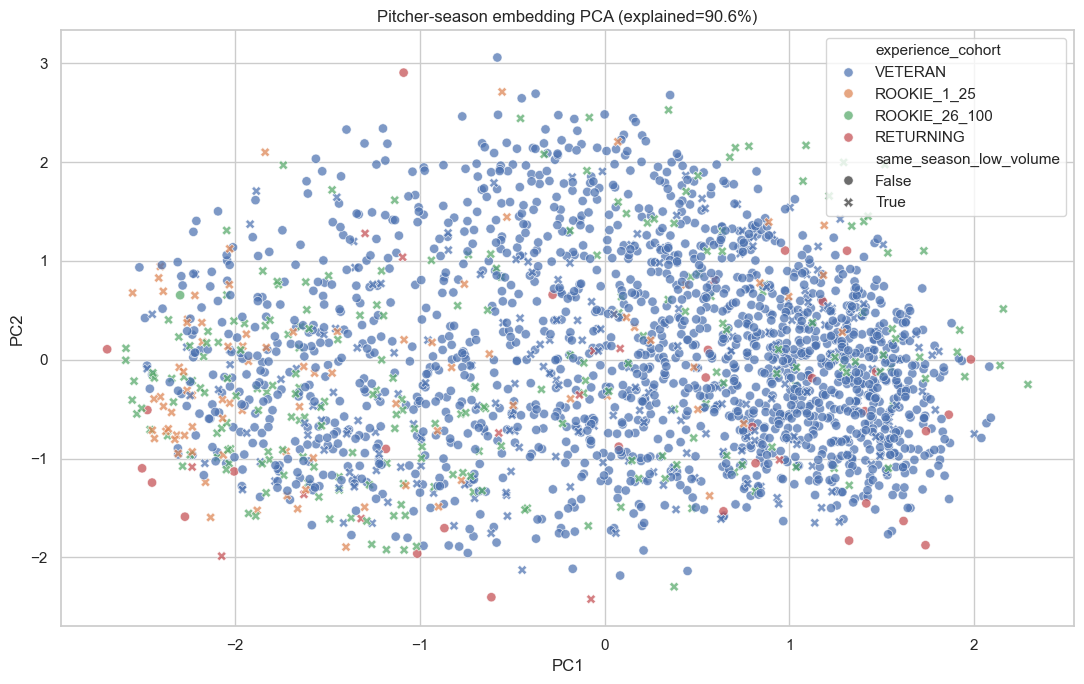

saved: C:\Users\isj67\Desktop\LGAIMERS\experiment\pitcher_embedding\outputs\pitcher_season_embeddings.parquet
embedding rows: 2260 dimension: 32


,pitcher_id,season,pitcher_trackman_id,cw_mean_sim,asof_pitcher_n,tm_prior_n,tm_prev_season_n,experience_cohort,same_season_pitch_n,same_season_low_volume,pred_success,embedding_00,embedding_01,embedding_02,embedding_03,embedding_04,embedding_05,embedding_06,embedding_07,embedding_08,embedding_09,embedding_10,embedding_11,embedding_12,embedding_13,embedding_14,embedding_15,embedding_16,embedding_17,embedding_18,embedding_19,embedding_20,embedding_21,embedding_22,embedding_23,embedding_24,embedding_25,embedding_26,embedding_27,embedding_28,embedding_29,embedding_30,embedding_31
0,20700,2019,99445.0,0.925940,665,0.0,0.0,VETERAN,666,False,0.594848,-0.105056,-0.128578,-0.226894,1.531958,-0.150039,2.202984,2.275317,0.099688,-0.214700,-0.233109,1.036497,-0.216004,-0.157979,0.404500,1.619674,-0.072580,0.664595,-0.179995,-0.176913,2.557220,-0.245734,-0.264372,-0.231874,-0.219676,-0.183105,-0.266374,-0.266649,-0.041666,-0.220175,-0.259298,-0.222906,-0.263379
1,20700,2020,99445.0,0.925940,958,596.0,596.0,VETERAN,293,False,0.523306,0.015883,-0.074378,-0.178512,1.637096,-0.136250,1.233840,2.510848,0.307478,-0.214757,-0.273346,1.074506,-0.178880,-0.165382,0.863783,2.151287,0.043596,0.023953,-0.161634,-0.109977,1.973013,-0.219424,-0.277487,-0.218584,-0.176886,-0.080218,-0.272163,-0.278231,0.020221,-0.247237,-0.270219,-0.176309,-0.278144
2,20938,2019,70425.0,0.888533,637,0.0,0.0,VETERAN,638,False,0.619678,-0.242099,-0.057619,-0.218082,1.644084,-0.204607,2.356153,1.998192,-0.057997,-0.170912,-0.261658,0.415326,-0.216538,-0.163437,1.811553,0.541091,-0.139046,1.149590,-0.042885,-0.026361,2.003594,-0.257588,-0.276533,-0.254348,-0.201683,-0.182771,-0.206350,-0.276201,0.312342,-0.236811,-0.249584,-0.066746,-0.277883
3,21095,2019,NaN,NaN,262,0.0,0.0,VETERAN,263,False,0.625543,-0.163741,-0.064685,-0.263174,1.469342,-0.220127,2.700095,2.189050,-0.113687,-0.214306,-0.193642,0.935129,-0.201073,-0.196667,0.468194,1.119621,-0.139318,1.040931,-0.174947,-0.197214,2.544175,-0.260563,-0.237310,-0.211243,-0.220700,-0.209768,-0.248285,-0.244065,-0.043683,-0.193659,-0.236241,-0.220154,-0.235651
4,21170,2021,71837.0,1.000000,19,0.0,0.0,ROOKIE_1_25,20,True,0.536998,-0.236476,0.231132,-0.095115,1.721806,-0.179328,1.505542,2.167032,-0.110380,-0.157251,-0.266763,0.933232,-0.232504,-0.152595,2.128173,0.715458,-0.164839,0.439139,-0.038864,0.163852,1.356955,-0.142005,-0.277732,-0.097725,-0.167820,-0.087150,-0.177358,-0.255016,0.099519,-0.274755,-0.251569,-0.051918,-0.231638


In [9]:
representative = (
    model_df.sort_values(["pitcher_id", "season", "asof_pitcher_n", "row_id"])
    .groupby(["pitcher_id", "season"], as_index=False, sort=False)
    .tail(1).copy()
)

rep_hist = hist_scaler.transform(hist_imputer.transform(representative[HISTORY_FEATURES])).astype("float32")
rep_tm = tm_scaler.transform(tm_imputer.transform(representative[TRACKMAN_FEATURES])).astype("float32")
rep_p, rep_c, rep_n = encode_metadata(representative)

dummy_y = np.zeros((len(representative), 4), dtype="float32")
rep_loader = make_loader(rep_hist, rep_tm, rep_p, rep_c, rep_n, dummy_y, False)
rep_prob, _, rep_embedding = predict_loader(rep_loader, return_embeddings=True)
rep_success_prob = np.prod(1 - rep_prob, axis=1)

embedding_cols = [f"embedding_{i:02d}" for i in range(rep_embedding.shape[1])]
embedding_table = representative[[
    "pitcher_id", "season", "pitcher_trackman_id", "cw_mean_sim", "asof_pitcher_n",
    "tm_prior_n", "tm_prev_season_n", "experience_cohort", "same_season_pitch_n",
    "same_season_low_volume",
]].reset_index(drop=True)
embedding_table["pred_success"] = rep_success_prob
embedding_table = pd.concat([embedding_table, pd.DataFrame(rep_embedding, columns=embedding_cols)], axis=1)

embedding_path = OUTPUT_DIR / "pitcher_season_embeddings.parquet"
embedding_table.to_parquet(embedding_path, index=False)
embedding_table.to_csv(OUTPUT_DIR / "pitcher_season_embeddings.csv", index=False)

pca = PCA(n_components=2, random_state=SEED)
xy = pca.fit_transform(rep_embedding)
plot_df = embedding_table[["pitcher_id", "season", "experience_cohort", "same_season_low_volume"]].copy()
plot_df["PC1"], plot_df["PC2"] = xy[:, 0], xy[:, 1]

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=plot_df, x="PC1", y="PC2", hue="experience_cohort",
    style="same_season_low_volume", alpha=.72, s=45,
)
plt.title(f"Pitcher-season embedding PCA (explained={pca.explained_variance_ratio_.sum():.1%})")
plt.tight_layout()
plot_path = OUTPUT_DIR / "pitcher_embedding_pca.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

artifact = {
    "model_state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
    "history_features": HISTORY_FEATURES,
    "trackman_features": TRACKMAN_FEATURES,
    "pitcher_to_index": pitcher_to_index,
    "cohort_to_index": cohort_to_index,
    "config": {"quick_run": QUICK_RUN, "epochs": EPOCHS, "seed": SEED, "embedding_dim": 32},
}
torch.save(artifact, OUTPUT_DIR / "pitcher_embedding_model.pt")
joblib.dump({
    "hist_imputer": hist_imputer, "hist_scaler": hist_scaler,
    "tm_imputer": tm_imputer, "tm_scaler": tm_scaler,
}, OUTPUT_DIR / "preprocessors.joblib")

print("saved:", embedding_path)
print("embedding rows:", len(embedding_table), "dimension:", len(embedding_cols))
display(embedding_table.head())


## 8. 다음 실험 순서

이 v0의 목적은 라벨, ID 연결, 시간 절단, 신인 shrinkage, 조건부 head가 한 파이프라인에서 정상 작동하는지 확인하는 것입니다.

다음 우선순위는 다음과 같습니다.

1. `QUICK_RUN=False`, 8~12 epoch로 전체 학습 후 2024 성능 재확인
2. 성공 단일 head 모델과 현재 3-head 모델을 같은 split에서 비교
3. Trackman 단순 집계를 최근 시즌/커리어 두 구간으로 분리
4. raw Trackman pitch set을 DeepSets encoder로 바꾸되, 이전 완료 시즌 pitch만 사용
5. 고신뢰 crosswalk 임계값 `0.80/0.02` 민감도 및 미연결 fallback 성능 비교
6. OOF/시간 순방향 임베딩을 팀 공용 feature schema에 맞춰 export

팀 공유 시에는 `pitcher_id`, `season`, `embedding_00..31`, `experience_cohort`, `tm_prior_n`, `cw_mean_sim`를 기본 계약으로 사용하면 됩니다.
